In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
df = pd.read_csv('/content/healthcare_fraud_detection.csv')

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Provider_ID                            10000 non-null  object 
 1   Claim_ID                               10000 non-null  object 
 2   Patient_Age                            10000 non-null  int64  
 3   Patient_Gender                         10000 non-null  object 
 4   Diagnosis_Code                         10000 non-null  object 
 5   Procedure_Code                         10000 non-null  int64  
 6   Claim_Amount                           10000 non-null  float64
 7   Approved_Amount                        10000 non-null  float64
 8   Insurance_Type                         9650 non-null   object 
 9   Claim_Submission_Date                  10000 non-null  object 
 10  Days_Between_Service_and_Claim         10000 non-null  int64  
 11  Num

In [25]:
df.isnull().sum()
print(df.isnull().sum())

Provider_ID                                0
Claim_ID                                   0
Patient_Age                                0
Patient_Gender                             0
Diagnosis_Code                             0
Procedure_Code                             0
Claim_Amount                               0
Approved_Amount                            0
Insurance_Type                           350
Claim_Submission_Date                      0
Days_Between_Service_and_Claim             0
Number_of_Claims_Per_Provider_Monthly      0
Provider_Specialty                       350
Patient_State                              0
Claim_Status                               0
Is_Fraud                                   0
Length_of_Stay                             0
Visit_Type                                 0
Chronic_Condition_Flag                     0
Prior_Visits_12m                         350
dtype: int64


In [26]:
df.duplicated().sum()
print(df.duplicated().sum())

0


In [27]:
df['Insurance_Type'] = df['Insurance_Type'].fillna(df['Insurance_Type'].mode()[0])
df['Provider_Specialty'] = df['Provider_Specialty'].fillna(df['Provider_Specialty'].mode()[0])
df['Prior_Visits_12m'] = df['Prior_Visits_12m'].fillna(df['Prior_Visits_12m'].mode()[0])

In [28]:
df.isnull().sum()
print(df.isnull().sum())

Provider_ID                              0
Claim_ID                                 0
Patient_Age                              0
Patient_Gender                           0
Diagnosis_Code                           0
Procedure_Code                           0
Claim_Amount                             0
Approved_Amount                          0
Insurance_Type                           0
Claim_Submission_Date                    0
Days_Between_Service_and_Claim           0
Number_of_Claims_Per_Provider_Monthly    0
Provider_Specialty                       0
Patient_State                            0
Claim_Status                             0
Is_Fraud                                 0
Length_of_Stay                           0
Visit_Type                               0
Chronic_Condition_Flag                   0
Prior_Visits_12m                         0
dtype: int64


In [29]:
df.describe()

,Patient_Age,Procedure_Code,Claim_Amount,Approved_Amount,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Is_Fraud,Length_of_Stay,Chronic_Condition_Flag,Prior_Visits_12m
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,49.755000,86905.21170,572.804406,475.514157,14.413800,68.628000,0.082900,2.19930,0.292000,3.025500
std,17.910144,14965.32496,406.202437,323.257165,8.489875,14.905872,0.275745,1.71046,0.454705,1.692376
min,1.000000,36415.00000,60.210000,50.350000,0.000000,42.000000,0.000000,0.00000,0.000000,0.000000
25%,37.750000,80053.00000,305.205000,257.200000,7.000000,60.000000,0.000000,1.00000,0.000000,2.000000
50%,50.000000,93000.00000,461.225000,388.370000,14.000000,66.000000,0.000000,2.00000,0.000000,3.000000
75%,62.000000,99213.00000,711.365000,598.347500,22.000000,72.000000,0.000000,3.00000,1.000000,4.000000
max,95.000000,99214.00000,6590.700000,4270.890000,29.000000,144.000000,1.000000,5.00000,1.000000,12.000000


In [30]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Patient_Age,10000.0,49.755000,17.910144,1.00,37.750,50.000,62.0000,95.00
Procedure_Code,10000.0,86905.211700,14965.324960,36415.00,80053.000,93000.000,99213.0000,99214.00
Claim_Amount,10000.0,572.804406,406.202437,60.21,305.205,461.225,711.3650,6590.70
Approved_Amount,10000.0,475.514157,323.257165,50.35,257.200,388.370,598.3475,4270.89
Days_Between_Service_and_Claim,10000.0,14.413800,8.489875,0.00,7.000,14.000,22.0000,29.00
Number_of_Claims_Per_Provider_Monthly,10000.0,68.628000,14.905872,42.00,60.000,66.000,72.0000,144.00
Is_Fraud,10000.0,0.082900,0.275745,0.00,0.000,0.000,0.0000,1.00
Length_of_Stay,10000.0,2.199300,1.710460,0.00,1.000,2.000,3.0000,5.00
Chronic_Condition_Flag,10000.0,0.292000,0.454705,0.00,0.000,0.000,1.0000,1.00
Prior_Visits_12m,10000.0,3.025500,1.692376,0.00,2.000,3.000,4.0000,12.00


In [31]:
df.describe(include ='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Provider_ID,10000,300,P0142,52,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Claim_ID,10000,10000,C0009983,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Patient_Age,10000.0,NaN,NaN,NaN,49.755,17.910144,1.0,37.75,50.0,62.0,95.0
Patient_Gender,10000,2,Female,5001,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Diagnosis_Code,10000,10,M54.5,1055,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Procedure_Code,10000.0,NaN,NaN,NaN,86905.2117,14965.32496,36415.0,80053.0,93000.0,99213.0,99214.0
Claim_Amount,10000.0,NaN,NaN,NaN,572.804406,406.202437,60.21,305.205,461.225,711.365,6590.7
Approved_Amount,10000.0,NaN,NaN,NaN,475.514157,323.257165,50.35,257.2,388.37,598.3475,4270.89
Insurance_Type,10000,4,Medicare,2775,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Claim_Submission_Date,10000,1476,2023-09-11,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN


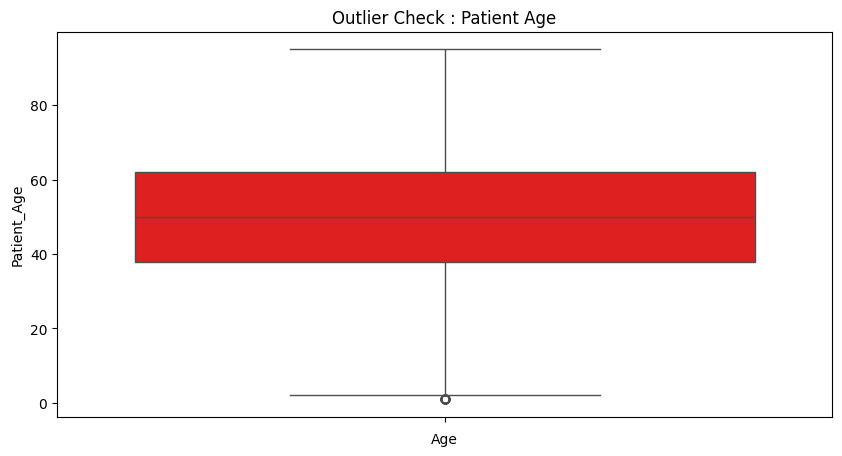

In [32]:
plt.figure(figsize=(10,5))
sns.boxplot(df['Patient_Age'],color='red')
plt.title("Outlier Check : Patient Age")
plt.xlabel('Age')
plt.show()

In [33]:
floor = df['Patient_Age'].quantile(0.05)
df['Patient_Age'] = df['Patient_Age'].clip(lower = floor)

In [34]:
df['Patient_Age'] = np.log(df['Patient_Age'])

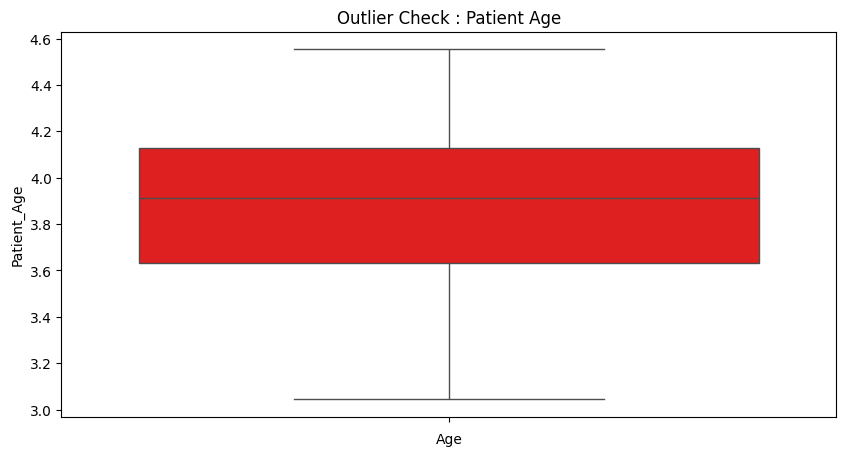

In [35]:
plt.figure(figsize=(10,5))
sns.boxplot(df['Patient_Age'],color='red')
plt.title("Outlier Check : Patient Age")
plt.xlabel('Age')
plt.show()

In [36]:
df.shape

(10000, 20)

In [37]:
df.dtypes

,0
Provider_ID,object
Claim_ID,object
Patient_Age,float64
Patient_Gender,object
Diagnosis_Code,object
Procedure_Code,int64
Claim_Amount,float64
Approved_Amount,float64
Insurance_Type,object
Claim_Submission_Date,object


In [38]:
from sklearn.preprocessing import LabelEncoder
import numpy as np
from numpy import astype

In [39]:
object_cols = df.select_dtypes(include = ['object']).columns
le = LabelEncoder()
for col in object_cols:
  df[col] = le .fit_transform(df[col].astype(str))
df = df.astype(int)
print(df.dtypes)

Provider_ID                              int64
Claim_ID                                 int64
Patient_Age                              int64
Patient_Gender                           int64
Diagnosis_Code                           int64
Procedure_Code                           int64
Claim_Amount                             int64
Approved_Amount                          int64
Insurance_Type                           int64
Claim_Submission_Date                    int64
Days_Between_Service_and_Claim           int64
Number_of_Claims_Per_Provider_Monthly    int64
Provider_Specialty                       int64
Patient_State                            int64
Claim_Status                             int64
Is_Fraud                                 int64
Length_of_Stay                           int64
Visit_Type                               int64
Chronic_Condition_Flag                   int64
Prior_Visits_12m                         int64
dtype: object


In [40]:
df.corr()

,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
Provider_ID,1.000000,0.009659,-0.010976,0.005640,0.001143,0.013034,0.003014,0.001485,0.005578,0.003264,-0.003324,0.004239,-0.044031,-0.001330,-0.000590,0.013016,0.001947,-0.012755,0.001971,0.000217
Claim_ID,0.009659,1.000000,0.008104,-0.021814,-0.003059,-0.011898,0.005632,0.006633,-0.004710,0.015305,-0.000401,-0.008676,-0.006301,0.006197,0.005578,-0.006656,0.005656,-0.013699,-0.004727,0.008502
Patient_Age,-0.010976,0.008104,1.000000,-0.009462,0.027405,0.020076,0.009338,0.012344,-0.004305,-0.029090,-0.002717,-0.009665,-0.004558,-0.008145,-0.010744,-0.016989,0.012754,-0.002142,-0.003085,0.002753
Patient_Gender,0.005640,-0.021814,-0.009462,1.000000,-0.006275,-0.005840,-0.026205,-0.027249,0.009165,-0.005031,-0.017824,0.012152,-0.002160,-0.000171,0.000251,-0.004655,0.022065,-0.000120,-0.015267,-0.002065
Diagnosis_Code,0.001143,-0.003059,0.027405,-0.006275,1.000000,0.068217,-0.000960,-0.005687,-0.010048,-0.002811,-0.003268,0.003742,-0.000603,0.009431,0.007426,0.013724,0.008533,0.001355,-0.015858,0.005846
Procedure_Code,0.013034,-0.011898,0.020076,-0.005840,0.068217,1.000000,-0.002016,-0.000251,0.011071,0.002025,0.003367,0.008830,0.006917,-0.003492,0.019442,0.003457,0.012353,-0.004825,-0.010137,-0.001924
Claim_Amount,0.003014,0.005632,0.009338,-0.026205,-0.000960,-0.002016,1.000000,0.937174,-0.000093,0.000508,-0.133841,0.042099,-0.013271,0.006827,0.083416,0.309500,0.012308,0.009185,-0.006459,0.017025
Approved_Amount,0.001485,0.006633,0.012344,-0.027249,-0.005687,-0.000251,0.937174,1.000000,-0.001822,-0.000662,-0.036152,0.007027,-0.014261,0.005788,0.003155,0.065458,0.012179,0.004332,-0.009827,0.016775
Insurance_Type,0.005578,-0.004710,-0.004305,0.009165,-0.010048,0.011071,-0.000093,-0.001822,1.000000,-0.006967,-0.001489,0.000793,-0.017063,0.006094,0.003758,-0.000963,-0.007762,-0.005104,-0.003613,0.011313
Claim_Submission_Date,0.003264,0.015305,-0.029090,-0.005031,-0.002811,0.002025,0.000508,-0.000662,-0.006967,1.000000,0.024866,0.001997,0.010405,0.003991,-0.009994,-0.006860,-0.012408,-0.001994,-0.004214,-0.003864


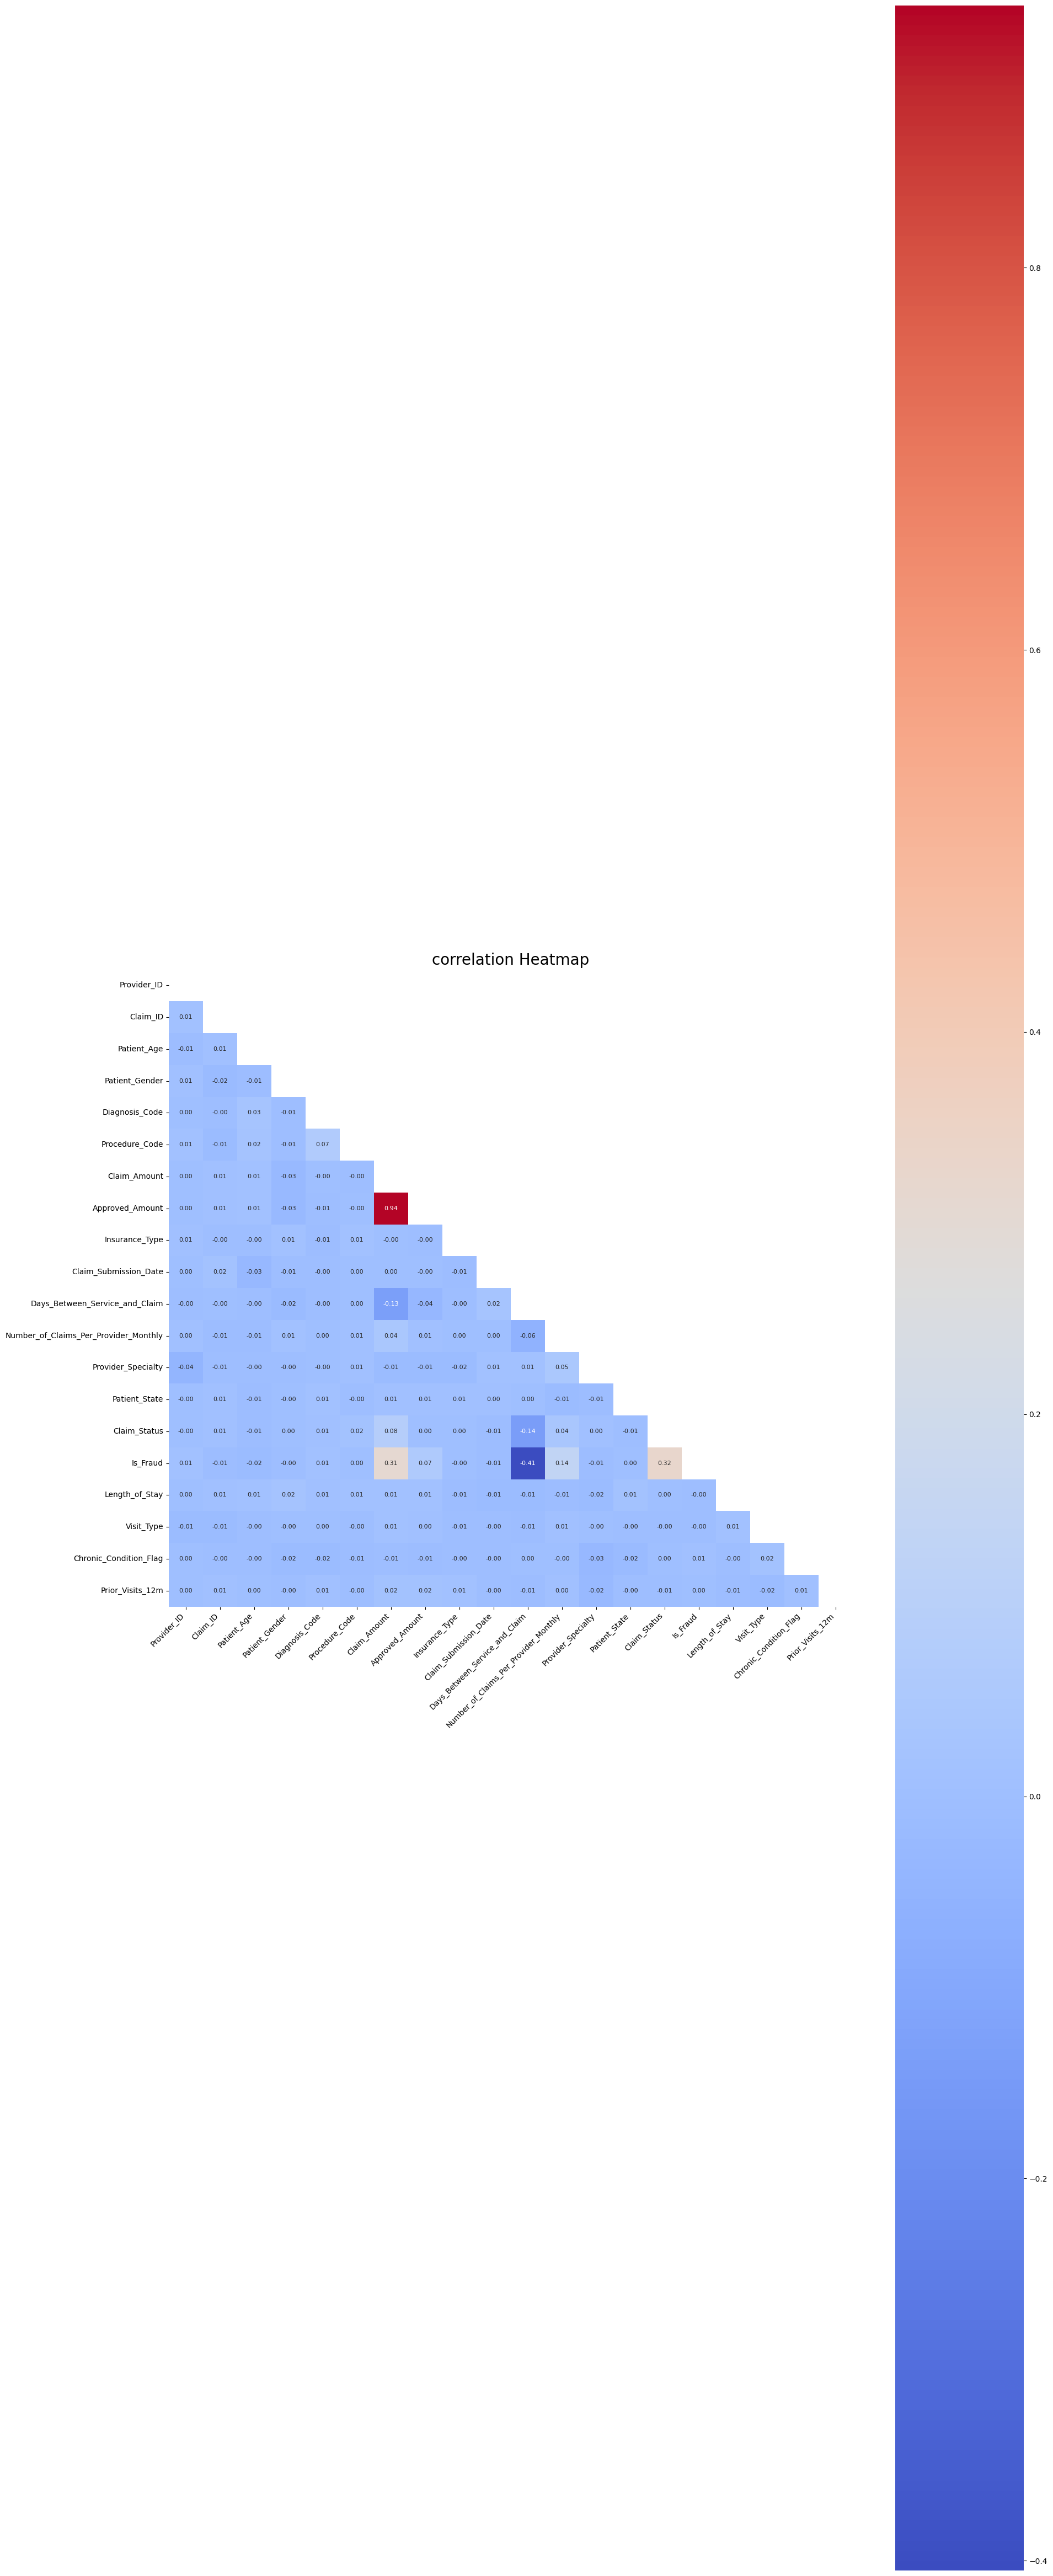

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# Increase fig size
plt.figure(figsize=(20,15))

# 2.Focus on the most important coorelations
corr = df.corr()

# 3.Create a mask to hide the top half
mask = np.triu(np.ones_like(corr))

# 4.Plot the heatmap
sns.heatmap(corr, mask = mask, annot = True, fmt ='.2f' , cmap = 'coolwarm', annot_kws = {"size": 8}, cbar_kws = {"shrink":8})
plt.title('correlation Heatmap',fontsize = 20)
plt.xticks(rotation =45, ha = 'right')
plt.show()

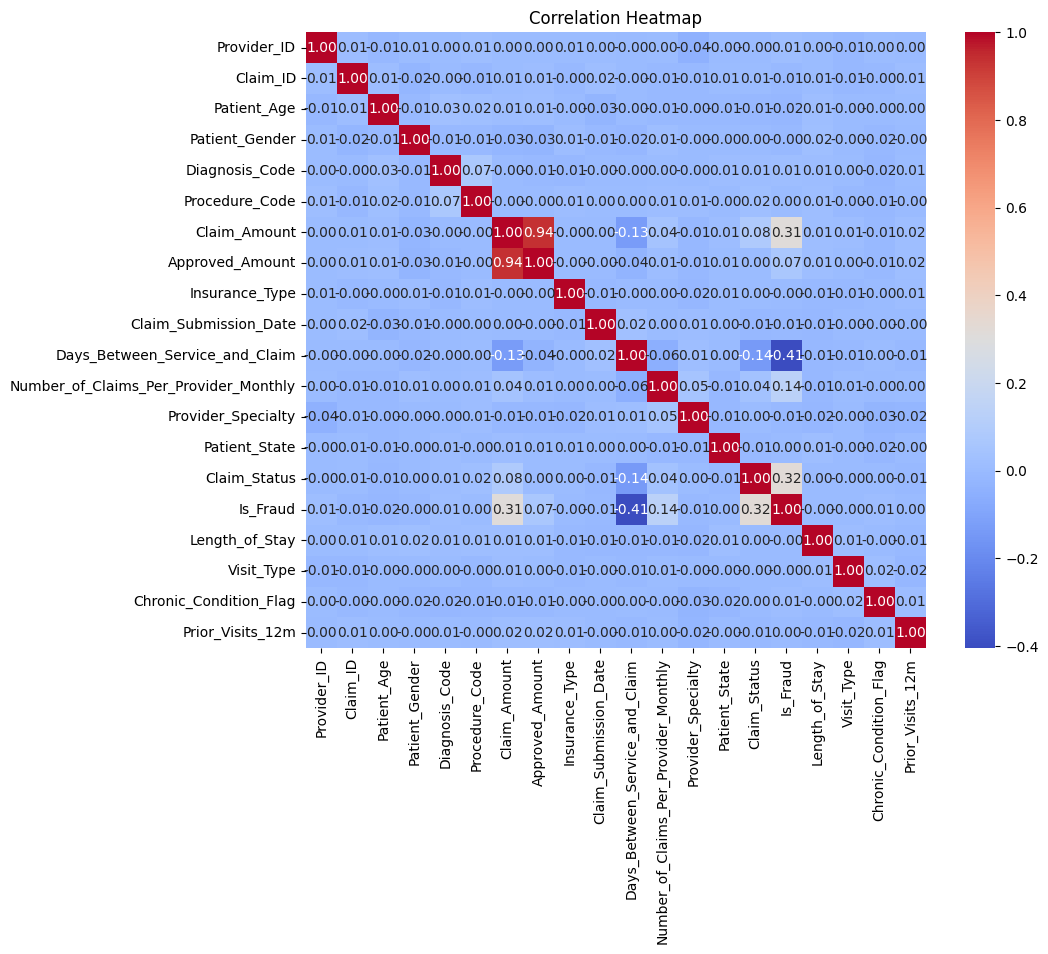

In [42]:
corr = df.corr()

# Plot the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr,annot=True,  cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()